In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [2]:
base_dir = Path("/network/group/aopp/predict/AWH029_WRIGHT_S2SPREC/cgan_training/uk_chenies")
# model_names = {
#     'batch=2': "logs_run7_5constants_batch2",
#     'batch=8': "logs_run7_5constants_batch8",
#     'batch=16': "logs_run7_5constants_batch16",
# }
# title = "5 constants, different batch sizes"
model_names = {
    'cl=100': "logs_run8_5constants_batch2_cl100",
    'cl=300': "logs_run8_5constants_batch2_cl300",
    'cl=1000': "logs_run8_5constants_batch2_cl1000",
}
title = "5 constants, different content loss values"

cl=100: Lowest CRPS = 0.032406 at N = 139776
cl=300: Lowest CRPS = 0.034588 at N = 140288
cl=1000: Lowest CRPS = 0.031757 at N = 150016


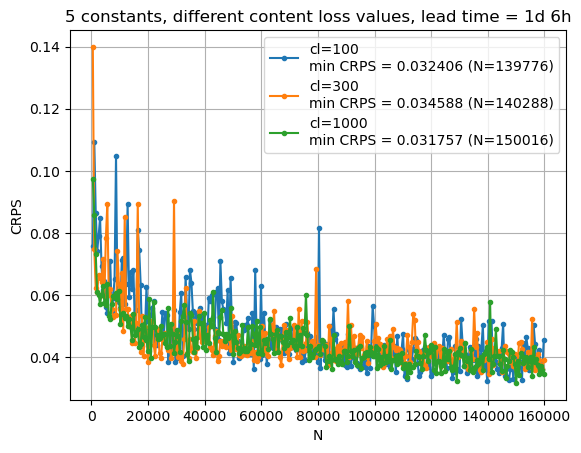

In [3]:
file_names = { key: base_dir /value / "eval_validation.txt" for key, value in model_names.items() }

for label, file_name in file_names.items():
    df = pd.read_csv(
        file_name,
        sep=r"\s+",
        header=3,
        # nrows=500,
        engine="python",
        on_bad_lines="warn",
    )

    df["CRPS"] = pd.to_numeric(df["CRPS"], errors="coerce")
    df["N"] = pd.to_numeric(df["N"], errors="coerce")

    min_idx = df["CRPS"].idxmin()
    min_crps = df.loc[min_idx, "CRPS"]
    best_N = int(df.loc[min_idx, "N"])

    print(f"{label}: Lowest CRPS = {min_crps:.6f} at N = {best_N}")

    plt.plot(df["N"], df["CRPS"], '.-',
            label=f"{label}\nmin CRPS = {min_crps:.6f} (N={best_N})")

plt.grid()
plt.xlabel("N")
plt.ylabel("CRPS")
plt.title(f"{title}, lead time = 1d 6h")
plt.legend()
plt.show()